<a href="https://colab.research.google.com/github/MateusAFalcao/RNA-e-Deep-Learning---CESAR-School-2025.02/blob/main/C%C3%B3pia_de_2_2_LinearRegressionIrisNumPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Linear com NumPy

## Objetivos deste experimento

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se programação totalmente NumPy com:
- o **cálculo do gradiente**,
- a **função de perda** e
- a atualização dos parâmetros são feitos de forma explícita.
- A rede é criada com uma camada como uma classe

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinear_Otimizacao.png)

## Importação dos pacotes

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt   # para plotting

from sklearn.datasets import load_iris  # para carregar dataset

import numpy as np  # processamento matricial

np.random.seed(1234)

## Dataset

### Leitura dos dados

In [2]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1]
y_train = data[:,1:2]

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float64
y_train.shape: (50, 1) float64
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [3]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()

Text(0, 0.5, 'Comprimento petalas')

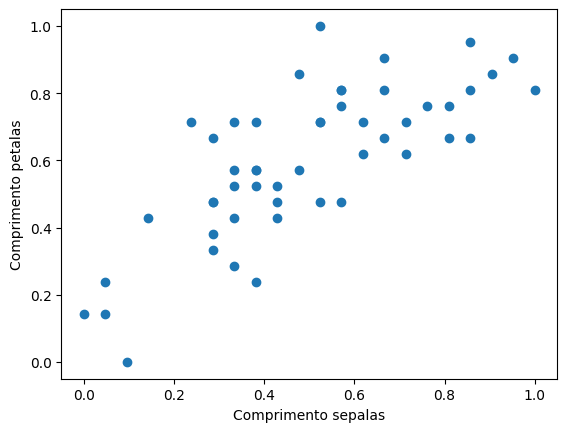

In [4]:
plt.scatter(x_train,y_train)
plt.xlabel('Comprimento sepalas')
plt.ylabel('Comprimento petalas')

## Modelo da rede

### Reta de ajuste

A equação da reta no plano necessita de dois parâmetros, aqui denominados $w_0$ (*bias*) e inclinação $w_1$. Veja figura:

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/linhareta.png)

A reta de ajuste será dada por:

$$ \hat{y} = w_0 + w_1 x $$

onde
* $w_1$ é o coeficiente angular da reta e
* $w_0$ é a interseção do eixo vertical quando x é igual a zero, também denominado de *bias*.
* $x$ é a variável de entrada (comprimento das sépalas) e
* $\hat{y}$ é a predição (comprimento estimado das pétalas).

### Linear Regression Model

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinearNeuronio.png)

### Formulação matricial do neurônio

* $\mathbf{w} = [w_0 \ w_1]$ é vetor linha de parâmetros e
* $\mathbf{x} = [1 \ x_0] $ é vetor linha de uma amostra (com *bias*).

$$ \hat{y} = 1 w_0 + x_0 w_1 $$

$$ [\hat{y}] = [1 \ x_0] \begin{bmatrix} w_0 \\ w_1 \end{bmatrix} $$

$$ \mathbf{\hat{y}} = \mathbf{x} \mathbf{w^T} $$

### Fazendo o predict de várias amostras

$$ \begin{matrix}
\begin{bmatrix}
\hat{y}_0\\
\hat{y}_1\\
\\
\hat{y}_{M-1}
\end{bmatrix} &=& \begin{bmatrix}
1 & x_0 \\
1 & x_1\\
\\
1 & x_{M-1} \\
\end{bmatrix}
&
\begin{bmatrix}
w_0\\
w_1
\end{bmatrix} \\
(M,1) & & (M,2) & (2,1) \\
\end{matrix} $$

### Preenchendo x com coluna de 1's para bias

In [5]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [6]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428571],
       [1.        , 0.95238095],
       [1.        , 0.28571429],
       [1.        , 0.76190476],
       [1.        , 0.38095238],
       [1.        , 0.66666667],
       [1.        , 0.        ],
       [1.        , 0.80952381],
       [1.        , 0.14285714],
       [1.        , 0.04761905],
       [1.        , 0.47619048],
       [1.        , 0.52380952],
       [1.        , 0.57142857],
       [1.        , 0.33333333],
       [1.        , 0.85714286],
       [1.        , 0.33333333],
       [1.        , 0.42857143],
       [1.        , 0.61904762],
       [1.        , 0.33333333],
       [1.        , 0.47619048],
       [1.        , 0.57142857],
       [1.        , 0.66666667],
       [1.        , 0.57142857],
       [1.        , 0.71428571],
       [1.        , 0.80952381],
       [1.        , 0.9047619 ],
       [1.        , 0.85714286],
       [1.        , 0.52380952],
       [1.        , 0.38095238],
       [1.

### Classe com o modelo da rede

In [7]:
class Net():
    def __init__(self, n_in, n_out):
        self.w = np.random.uniform(-0.1,0.1,(n_out,n_in)) #inicialização dos parâmetros

    def forward(self, x_bias):
        return x_bias.dot(self.w.T)

### Criando a rede, instanciando o objeto model

In [8]:
model = Net(2,1) # duas entradas (1 + x0) e uma saída y_pred

### Tarefa 2 - Perda ANTES do treinamento

In [9]:
y_pred_inicial = model.forward(x_train_bias)
loss_inicial = np.square(y_pred_inicial - y_train).mean()
print(f"[TAREFA 2] MSE com pesos iniciais (sem treinamento): {loss_inicial:.6f}")
print(f"           Pesos iniciais: {model.w}\n")

[TAREFA 2] MSE com pesos iniciais (sem treinamento): 0.469163
           Pesos iniciais: [[-0.06169611  0.02442175]]



### Testando o predict da rede (mesmo sem treiná-la)

In [10]:
xin = np.random.randn(4,2) # 4 amostras, 2 entradas (1 + x0)
ypred = model.forward(xin)
ypred

array([[-0.09602795],
       [ 0.0661236 ],
       [-0.06857828],
       [-0.05573871]])

## Treinamento via gradiente descendente

Função de perda:
$$ J(\hat{y_i},y_i) = \frac{1}{M} \sum_{i=0}^{M-1} (\hat{y_i} - y_i)^2 $$

Gradiente:
$$  \mathbf{\nabla{J_w}} = \frac{2}{M}\mathbf{x^T}(\mathbf{x w^T} - \mathbf{y}) $$

Atualização dos parâmetros pelo gradiente descendente:
$$ \mathbf{w} = \mathbf{w} − \eta (\mathbf{\nabla J_w})^T $$

### Laço de treinamento

### TAREFA 1 — Laço de treinamento salvando a perda por época

Epoch [1/100], loss: 0.469163
Epoch [2/100], loss: 0.058070
Epoch [3/100], loss: 0.030543
Epoch [4/100], loss: 0.028105
Epoch [5/100], loss: 0.027364
Epoch [6/100], loss: 0.026787
Epoch [7/100], loss: 0.026269
Epoch [8/100], loss: 0.025799
Epoch [9/100], loss: 0.025373
Epoch [10/100], loss: 0.024986
Epoch [11/100], loss: 0.024634
Epoch [12/100], loss: 0.024315
Epoch [13/100], loss: 0.024025
Epoch [14/100], loss: 0.023762
Epoch [15/100], loss: 0.023524
Epoch [16/100], loss: 0.023307
Epoch [17/100], loss: 0.023110
Epoch [18/100], loss: 0.022931
Epoch [19/100], loss: 0.022769
Epoch [20/100], loss: 0.022622
Epoch [21/100], loss: 0.022488
Epoch [22/100], loss: 0.022366
Epoch [23/100], loss: 0.022256
Epoch [24/100], loss: 0.022156
Epoch [25/100], loss: 0.022065
Epoch [26/100], loss: 0.021983
Epoch [27/100], loss: 0.021908
Epoch [28/100], loss: 0.021840
Epoch [29/100], loss: 0.021778
Epoch [30/100], loss: 0.021722
Epoch [31/100], loss: 0.021671
Epoch [32/100], loss: 0.021625
Epoch [33/100], l

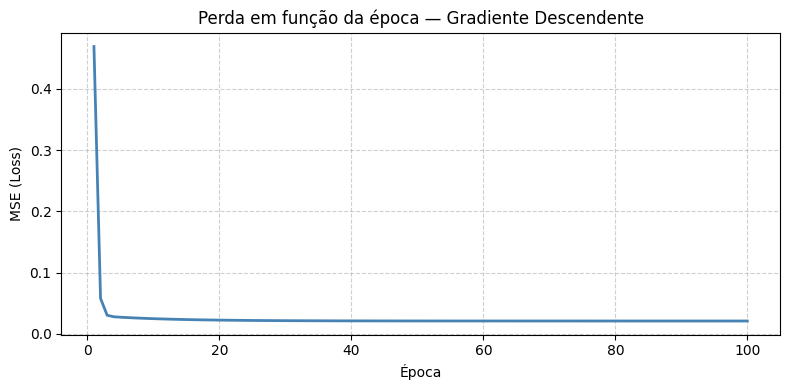

In [11]:
num_epochs = 100
learning_rate = 0.5
perda = []

for epoch in range(num_epochs):

    # forward - predict
    y_pred = model.forward(x_train_bias)

    #loss cálculo da função de perda
    loss = np.square(y_pred - y_train).mean()

    # Guarda a perda da época atual
    perda.append(loss)   # salvando aqui perdas na lista

    # cálculo do gradiente pelas derivadas parciais
    w_grad = (2.0/n_samples) * (x_train_bias.T).dot(x_train_bias.dot(model.w.T) - y_train)

    # gradiente descendente
    model.w = model.w - learning_rate * w_grad.T

    # verbose
    if (epoch+1) % 1 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], loss: {loss:.6f}")

# Plot da perda em função da época
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), perda, color='steelblue', linewidth=2)
plt.xlabel('Época')
plt.ylabel('MSE (Loss)')
plt.title('Perda em função da época — Gradiente Descendente')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Avaliação

### Predict

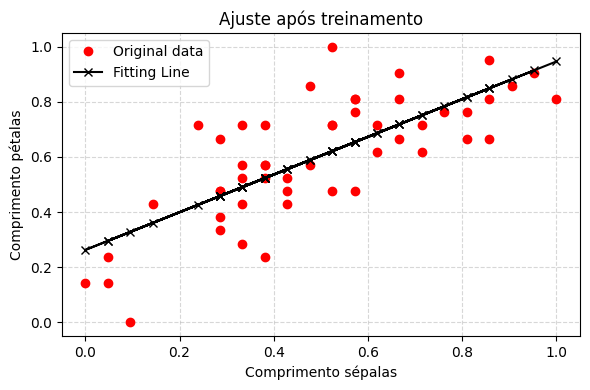

In [12]:
y_pred_final = model.forward(x_train_bias)
loss_gd      = np.square(y_pred_final - y_train).mean()

plt.figure(figsize=(6, 4))
plt.plot(x_train, y_train,    'ro',  label='Original data')
plt.plot(x_train, y_pred_final, 'kx-', label='Fitting Line')
plt.xlabel('Comprimento sépalas')
plt.ylabel('Comprimento pétalas')
plt.legend()
plt.title('Ajuste após treinamento')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Parâmetros treinados

In [13]:
print(model.w)

[[0.26295353 0.68335641]]


### Avaliação do modelo

In [14]:
loss = np.square(y_pred - y_train).mean()
loss

np.float64(0.021170062593862105)

### Valor ótimo, solução analítica

$$  \mathbf{w} =(\mathbf{x^T} \mathbf{x})^{−1}\mathbf{x^T} \mathbf{y} $$

In [15]:
x = x_train_bias
y = y_train
w_opt = (np.linalg.inv((x.T).dot(x)).dot(x.T)).dot(y)
print(w_opt.T)

[[0.26134159 0.68646976]]


### TAREFA 3 — Solução analítica ótima e comparação

In [16]:
# Coloca os pesos ótimos no modelo
model.w = w_opt.T

# Calcula o MSE com os pesos ótimos
y_pred_opt = model.forward(x_train_bias)
loss_opt   = np.square(y_pred_opt - y_train).mean()

In [17]:
# Comparação final
print(f"\n--- Comparação de MSE ---")
print(f"  Pesos iniciais (sem treino) : {loss_inicial:.6f}")
print(f"  Gradiente Descendente       : {loss_gd:.6f}")
print(f"  Solução Analítica Ótima     : {loss_opt:.6f}")


--- Comparação de MSE ---
  Pesos iniciais (sem treino) : 0.469163
  Gradiente Descendente       : 0.021170
  Solução Analítica Ótima     : 0.021169


# Exercícios

## Questões

1. Quantos parâmetros são treinados nesse modelo?

2. Qual é o número de atributos de entrada para a rede?

3. Qual é o número de saídas da rede?

4. Suponha que eu tenha agora 5 mil amostras para fazer a predição. Qual é o shape da matriz de entrada?
   Qual é o shape do matriz de saída?


## Atividades

1. Modifique o laço do treinamento via gradiente descendente para guardar em uma lista, o valor da perda no final
   de cada época. Após o treinamento, plote o valor da perda em função da época.
2. Calcule o valor da perda (MSE) da rede com os parâmetros inicializados, sem serem treinados.
3. Coloque os valores dos pesos da solução ótima analítica no modelo da rede e calcule o valor da perda (MSE) e
   compare com o valor da perda obtida pelo método da otimização via gradiente descendente.

# Aprendizados

Na tarefa 1, o resultado é o esperado, queda grande nas primeiras épocas e estabilização progressiva (quanto mais próximo do mínimo a perda começa a cair).

Na tarefa 2, o MSE inicial foi 0.4692, bem longe do ótimo. Isso confirma que pesos aleatórios pequenos (uniform -0.1, 0.1) produzem predições ruins e que o treinamento é de necessário.

Na atividade 3, comparando os resultados dos MSEs, vemos que a perda caiu de 0.469 para 0.021 após o treinamento. Os resultados do Gradiente Descendente e da Solução Analítica foram praticamente iguais.